# Supermart Sales Analysis Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('supermarket_sales.csv')
df.head()


,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.info
df.describe


<bound method NDFrame.describe of       invoice_id branch       city customer_type gender_customer  \
0    750-67-8428      A     Yangon        Member          Female   
1    226-31-3081      C  Naypyitaw        Normal          Female   
2    631-41-3108      A     Yangon        Normal            Male   
3    123-19-1176      A     Yangon        Member            Male   
4    373-73-7910      A     Yangon        Normal            Male   
..           ...    ...        ...           ...             ...   
995  233-67-5758      C  Naypyitaw        Normal            Male   
996  303-96-2227      B   Mandalay        Normal          Female   
997  727-02-1313      A     Yangon        Member            Male   
998  347-56-2442      A     Yangon        Normal            Male   
999  849-09-3807      A     Yangon        Member          Female   

               product_line  unit_cost  quantity  5pct_markup    revenue  \
0         Health and beauty      74.69         7      26.1415   548.9715 

In [5]:
df.shape
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='object')

In [6]:
df.isnull().sum()

invoice_id         0
branch             0
city               0
customer_type      0
gender_customer    0
product_line       0
unit_cost          0
quantity           0
5pct_markup        0
revenue            0
date               0
time               0
payment_method     0
cogs               0
gm_pct             0
gross_income       0
rating             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.head()

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


df['date'] =pd.to_datetime(df['date'])
df['Month']=df['date'].dt.month_name()
df['Day'] =df['date'].dt.day_name()
df['Hour']=pd.to_datetime(df['time']).dt.hour

print(df.dtypes)

df[['date','Month','Day','Hour']].head()

### Top Products

In [18]:
top_products = df.groupby('product_line')['revenue'].sum().sort_values(ascending=False)
print(top_products)

product_line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: revenue, dtype: float64


### Hourly sales

In [21]:
hourly_sales = df.groupby('Hour')['revenue'].sum()
print(hourly_sales)

Hour
10    31421.4810
11    30377.3295
12    26065.8825
13    34723.2270
14    30828.3990
15    31179.5085
16    25226.3235
17    24445.2180
18    26030.3400
19    39699.5130
20    22969.5270
Name: revenue, dtype: float64


### Daily sales

In [22]:
daily_sales = df.groupby('Day')['revenue'].sum().sort_values(ascending=False)
print(daily_sales)

Day
Saturday     56120.8095
Tuesday      51482.2455
Thursday     45349.2480
Sunday       44457.8925
Friday       43926.3405
Wednesday    43731.1350
Monday       37899.0780
Name: revenue, dtype: float64


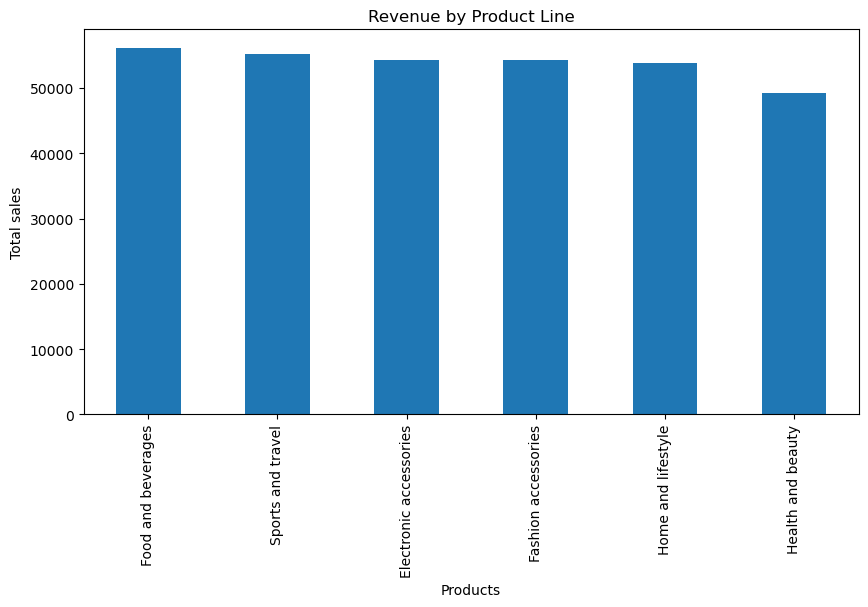

In [28]:
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Revenue by Product Line')
plt.xlabel('Products')
plt.ylabel('Total sales')
plt.show()

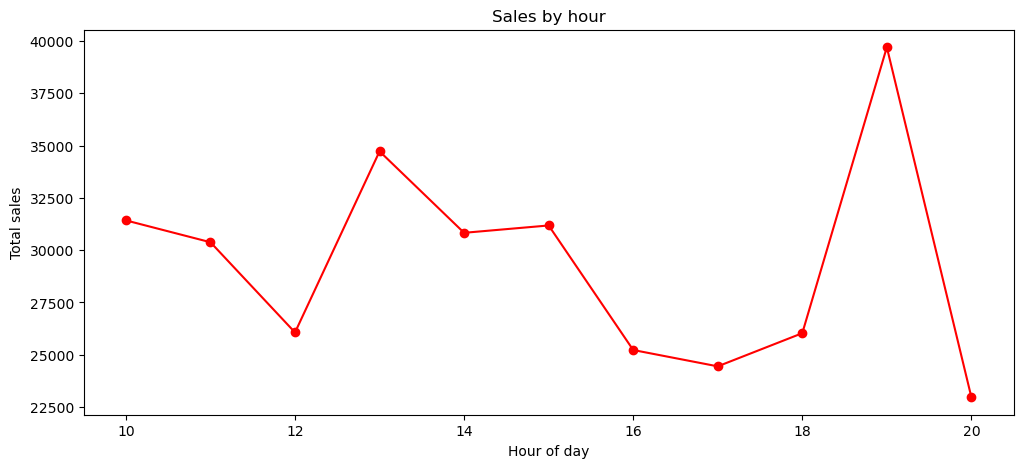

In [34]:
plt.figure(figsize=(12,5))
hourly_sales.plot(kind='line',marker='o',color='red')
plt.title('Sales by hour')
plt.xlabel('Hour of day')
plt.ylabel('Total sales')
plt.show()

### Pareto Analysis

This shows which section contibute the most.

In [35]:
product_pct=(top_products/top_products.sum())*100
cumulative_pct=product_pct.cumsum()
print(cumulative_pct)

product_line
Food and beverages         17.384094
Sports and travel          34.451742
Electronic accessories     51.276239
Fashion accessories        68.090941
Home and lifestyle         84.768172
Health and beauty         100.000000
Name: revenue, dtype: float64


### Customer Type

In [37]:
customer_analysis=df.groupby('customer_type')['revenue'].sum()
print(customer_analysis)

customer_type
Member    164223.444
Normal    158743.305
Name: revenue, dtype: float64


### Payment method

In [39]:
payment_method=df.groupby('payment_method')['revenue'].sum()
print(payment_method)

payment_method
Cash           112206.570
Credit card    100767.072
Ewallet        109993.107
Name: revenue, dtype: float64


# INSIGHTS

1. All line of products generate almost equal amount of revenue.The least is health and beauty.

2. Peak sales hours is around 6pm to 8pm.

3. Saturday has highest footfall.

4. Cash is most preferred payment method.

5. Monday has the least revenue in all days.